In [1]:
from statistics import LinearRegression

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as skl
import warnings

from sklearn.linear_model import Ridge

warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
# Import data from file
df = pd.read_csv('data/student_data_train.csv')
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [3]:
df.shape

(1000, 10)

In [4]:
# Creating Independent and Dependent features
X = df.drop('total_score', axis=1)
y = df['total_score']

In [5]:
numeric_features = X.select_dtypes(include='number').columns.tolist()
categorical_features = X.select_dtypes(include=['category', 'str']).columns.tolist()

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, categorical_features),
        ("StandardScaler", numeric_transformer, numeric_features),
    ]
)

In [6]:
X = preprocessor.fit_transform(X)

In [7]:
# Train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
def evaluate_model(true, pred):
    MAE = skl.metrics.mean_absolute_error(true, pred)
    MSE = skl.metrics.mean_squared_error(true, pred)
    RMSE = skl.metrics.root_mean_squared_error(true, pred)
    R2 = skl.metrics.r2_score(true, pred)
    return MAE, MSE, RMSE, R2

In [15]:
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

models = {
    "LinearRegression": skl.linear_model.LinearRegression(),
    "Ridge": skl.linear_model.Ridge(),
    "Lasso": skl.linear_model.Lasso(),
    "KNN": skl.neighbors.KNeighborsRegressor(),
    "SVR": skl.svm.SVR(),
    "DecisionTree": skl.tree.DecisionTreeRegressor(),
    "RandomForest": skl.ensemble.RandomForestRegressor(),
    "AdaBoost": skl.ensemble.AdaBoostRegressor(),
    "GradientBoost": skl.ensemble.GradientBoostingRegressor(),
    "XGBoost": XGBRegressor(),
    "CatBoost": CatBoostRegressor(),
}

In [25]:
model_dict = {}
r2_dict = {}
mae_dict = {}
mse_dict = {}
rmse_dict = {}

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)
    name = list(models.keys())[i]

    #make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    #Evaluating model on train and test dataset
    train_mae, train_mse, train_rmse, train_r2 = evaluate_model(y_train, y_train_pred)
    test_mae, test_mse, test_rmse, test_r2 = evaluate_model(y_test, y_test_pred)

    model_dict.update({name: model})
    print(f"{name} :")
    print('Model Train set')
    print(f"R² score: {train_r2}")
    print(f"MAE: {train_mae}")
    print(f"MSE: {train_mse}")
    print(f"RMSE: {train_rmse}")
    print()
    print('Model Test set')
    print(f"R2 score: {test_r2}")
    print(f"MAE: {test_mae}")
    print(f"MSE: {test_mse}")
    print(f"RMSE: {test_rmse}")
    print('———————————————————————————————————')

    r2_dict.update({name: test_r2})
    mae_dict.update({name: test_mae})
    mse_dict.update({name: test_mse})
    rmse_dict.update({name: test_rmse})

LinearRegression :
Model Train set
R² score: 1.0
MAE: 1.4512835377900046e-14
MSE: 5.051234148311183e-28
RMSE: 2.2474950830449403e-14

Model Test set
R2 score: 1.0
MAE: 1.3642420526593923e-14
MSE: 4.685202688288633e-28
RMSE: 2.1645329030274944e-14
———————————————————————————————————
Ridge :
Model Train set
R² score: 0.9999998275513584
MAE: 0.014251319027286212
MSE: 0.0003095530621816178
RMSE: 0.017594120102512024

Model Test set
R2 score: 0.9999998064764087
MAE: 0.014683893416675104
MSE: 0.0003733648904986972
RMSE: 0.019322652263566126
———————————————————————————————————
Lasso :
Model Train set
R² score: 0.9994328035509327
MAE: 0.8075024891061073
MSE: 1.0181431180112765
RMSE: 1.0090307814984023

Model Test set
R2 score: 0.999422299105941
MAE: 0.831174438327183
MSE: 1.1145578149771884
RMSE: 1.0557262026572933
———————————————————————————————————
KNN :
Model Train set
R² score: 0.9803040586125157
MAE: 4.672999999999999
MSE: 35.35509999999999
RMSE: 5.946015472566481

Model Test set
R2 score

In [27]:
pd.DataFrame(list(zip(model_dict.keys(), r2_dict.values(), mae_dict.values(), mse_dict.values(), rmse_dict.values())),
             columns=['Model', 'R2', 'MAE', 'MSE', 'RMSE']).sort_values(by=['R2'],
                                                                        ascending=False)

,Model,R2,MAE,MSE,RMSE
0,LinearRegression,1.000000,1.364242e-14,4.685203e-28,2.164533e-14
1,Ridge,1.000000,1.468389e-02,3.733649e-04,1.932265e-02
2,Lasso,0.999422,8.311744e-01,1.114558e+00,1.055726e+00
5,DecisionTree,0.997818,2.800000e-01,4.210000e+00,2.051828e+00
8,GradientBoost,0.997739,4.444735e-01,4.362961e+00,2.088770e+00
9,XGBoost,0.997429,5.281583e-01,4.960259e+00,2.227164e+00
6,RandomForest,0.995919,3.609500e-01,7.873277e+00,2.805936e+00
10,CatBoost,0.994960,9.447717e-01,9.724483e+00,3.118410e+00
7,AdaBoost,0.993261,2.108127e+00,1.300233e+01,3.605875e+00
3,KNN,0.966842,5.769000e+00,6.397220e+01,7.998262e+00


In [39]:
# Choosing Ridge Regression model from the above stats
ridge = skl.linear_model.Ridge(fit_intercept=True)
ridge.fit(X_train, y_train)
y_pred = ridge.predict(X_test)
score = skl.metrics.r2_score(y_test, y_pred)
print(f'Accuracy of model: %2.f%%' % (score * 100))

Accuracy of model: 100%


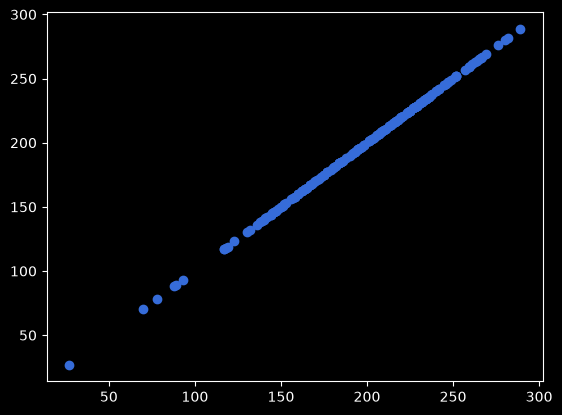

In [46]:
# Plot y_pred and y_test
plt.scatter(y_test, y_pred)

<Axes: xlabel='total_score'>

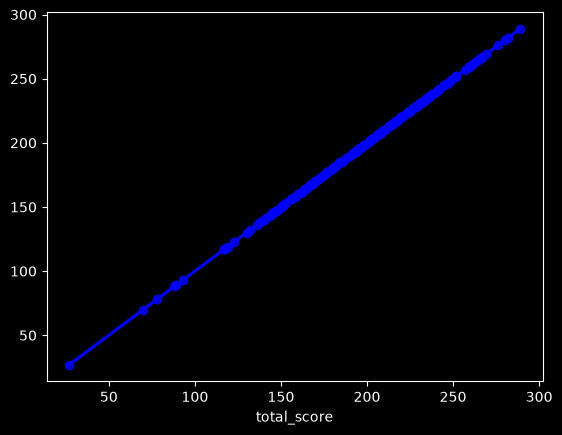

In [50]:
sns.regplot(x=y_test, y=y_pred, ci=None, color='blue')

In [51]:
pred_df = pd.DataFrame({'Actual Value': y_test, "Predicted Value": y_pred, 'Difference': y_test - y_pred})

In [52]:
pred_df

,Actual Value,Predicted Value,Difference
521,261,260.979635,0.020365
737,192,191.995764,0.004236
740,225,224.998383,0.001617
660,224,223.974598,0.025402
411,245,245.001002,-0.001002
...,...,...,...
408,165,165.020982,-0.020982
332,171,171.034537,-0.034537
208,231,230.979681,0.020319
613,216,216.001187,-0.001187
